<a href="https://colab.research.google.com/github/Ramprashanth17/Gen_AI/blob/main/rag-learning-platform/notebooks/3_Vector_Storage_Chromadb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Tutorial 03: Vector Storage with ChromaDB

**Learning Objectives:**
- Understand what vector databases are and why RAG needs them
- Learn the difference between traditional databases and vector databases
- Master ChromaDB setup and operations
- Store embeddings with metadata for production RAG
- Query for similar documents using vector search
- Visualize search results and similarity scores

**Prerequisites:**
- ✅ Completed `01_embeddings_fundamentals.ipynb`
- ✅ Completed `02_chunking_and_tokenization.ipynb`
- ✅ Understand embeddings, chunking, and cosine similarity

**Time Required:** 40-50 minutes

---

## 📖 Table of Contents
1. [The Problem: Finding the Needle in the Haystack](#problem)
2. [What Are Vector Databases?](#vectordb)
3. [ChromaDB Basics](#chromadb)
4. [Storing Documents with Metadata](#storing)
5. [Querying and Retrieval](#querying)
6. [Visualizing Results](#visualization)
7. [Best Practices](#practices)
8. [Practice Exercises](#exercises)

---

**Author:** Ramprashanth | INFO 7390 Final Project | December 2025

**🔗 Previous Tutorials:**
- [01_embeddings_fundamentals.ipynb](01_embeddings_fundamentals.ipynb)
- [02_chunking_and_tokenization.ipynb](02_chunking_and_tokenization.ipynb)

**⏭️ Next Tutorial:**
- 04_rag_pipeline_complete.ipynb

In [1]:
# Install packages
!pip install -q chromadb sentence-transformers google-generativeai tiktoken

In [2]:
# Imports
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
import json

print("✅ Setup complete! Let's explore vector databases.")
print(f"📦 ChromaDB version: {chromadb.__version__}")

✅ Setup complete! Let's explore vector databases.
📦 ChromaDB version: 1.3.5


<a id="problem"></a>
## 🔍 The Problem: Finding the Needle in the Haystack

### The Scenario

You've built a knowledge base with **10,000 documents** about pet care. Now you need to:
```python
# User asks a question
query = "What vaccines do puppies need?"

# You need to find the 3 most relevant documents
# from 10,000 options... HOW? 🤔
```

---

### ❌ Approach 1: Traditional Database (SQL)
```sql
-- Traditional keyword search
SELECT * FROM documents
WHERE content LIKE '%vaccine%'
  AND content LIKE '%puppy%'
LIMIT 3;
```

**Problems:**
- ❌ **Misses synonyms:** "immunization" won't match "vaccine"
- ❌ **No semantic understanding:** "shots" ≠ "vaccine" to SQL
- ❌ **Word order matters:** "puppy vaccine" ≠ "vaccine puppy"
- ❌ **No similarity ranking:** How similar is each result?

**Example of what you'd miss:**
```
Query: "What vaccines do puppies need?"
Missed document: "Essential immunizations for young dogs"
↑ Same meaning, different words! SQL won't find it.
```

---

### ✅ Approach 2: Vector Database
```python
# Convert query to embedding
query_vector = model.encode("What vaccines do puppies need?")
# Result: [0.23, 0.89, ..., 0.45] (384 numbers)

# Find documents with similar vectors
results = vector_db.search(
    query_vector=query_vector,
    top_k=3
)

# Returns:
# 1. "Essential immunizations for young dogs" (similarity: 0.94) ✅
# 2. "Puppy vaccination schedule guide" (similarity: 0.91) ✅
# 3. "When to vaccinate your new puppy" (similarity: 0.89) ✅
```

**Benefits:**
- ✅ **Understands meaning:** Finds "immunization" when you search "vaccine"
- ✅ **Semantic search:** Knows "puppy" and "young dog" are related
- ✅ **Ranked by similarity:** Best matches first
- ✅ **Fast:** Millions of vectors searched in milliseconds

---

### 🎯 The Key Insight
```
Traditional DB:    Text → Exact match → Results
Vector DB:         Text → Embedding → Similarity search → Results
                         ↑           ↑
                    Captures     Finds semantic
                    meaning      similarity
```

**This is why RAG systems NEED vector databases!**

<a id="vectordb"></a>
## 🗄️ What Are Vector Databases?

### Definition

A **vector database** is a specialized database designed to store and search high-dimensional vectors efficiently.

---

### The Analogy: Library Systems

#### Traditional Library (SQL Database):
```
Search: "Find books with 'machine learning' in the title"
Method: Exact text matching
Result: Only books with those exact words

📚 "Machine Learning Basics" ✅
📚 "Introduction to ML" ❌ (Missing!)
📚 "AI and Deep Learning" ❌ (Missing!)
```

#### Smart Library (Vector Database):
```
Search: "Find books about machine learning"
Method: Semantic similarity (understands meaning)
Result: All related books, ranked by relevance

📚 "Machine Learning Basics" (0.95) ✅
📚 "Introduction to ML" (0.92) ✅
📚 "AI and Deep Learning" (0.88) ✅
```

---

### How Vector Databases Work
```
┌──────────────────────────────────────────────────────────┐
│  STEP 1: STORE                                           │
├──────────────────────────────────────────────────────────┤
│  Document: "Dogs need daily exercise"                    │
│  ↓ Embed                                                 │
│  Vector: [0.23, 0.89, 0.12, ..., 0.45] (384 dims)      │
│  ↓ Store with metadata                                   │
│  ID: doc_001                                             │
│  Vector: [...]                                           │
│  Metadata: {source: "care_guide.pdf", page: 5}         │
└──────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────┐
│  STEP 2: SEARCH                                          │
├──────────────────────────────────────────────────────────┤
│  Query: "What do dogs need?"                             │
│  ↓ Embed                                                 │
│  Query Vector: [0.25, 0.87, 0.14, ..., 0.43]           │
│  ↓ Find similar vectors (cosine similarity!)            │
│  Result: doc_001 (similarity: 0.94)                      │
│  ↓ Return with metadata                                  │
│  "Dogs need daily exercise" + {source: ..., page: 5}    │
└──────────────────────────────────────────────────────────┘
```

---

### Vector Database vs Traditional Database

| Feature | Traditional (SQL) | Vector DB |
|---------|-------------------|-----------|
| **Storage** | Tables with rows/columns | Vectors + metadata |
| **Search Method** | Exact match / LIKE | Similarity search |
| **Query** | `WHERE name = 'dog'` | `SIMILAR_TO(vector)` |
| **Speed** | Fast for exact match | Fast for similarity |
| **Use Case** | Structured data | Semantic search, RAG |
| **Understands meaning** | ❌ No | ✅ Yes |

---

### Popular Vector Databases

| Database | Best For | Why Use It |
|----------|----------|------------|
| **ChromaDB** | Learning, prototypes | ✅ Easy setup, local-first |
| **Pinecone** | Production, scale | Cloud-managed, fast |
| **Weaviate** | Enterprise | Feature-rich, GraphQL |
| **Milvus** | Large scale | Open-source, distributed |
| **FAISS** | Research | Facebook's library, fast |

**We're using ChromaDB because:**
- ✅ Dead simple to set up (2 lines of code!)
- ✅ Works in Colab without external services
- ✅ Perfect for learning and small projects
- ✅ Can scale to production later

## ChromaDB Basics

In [3]:
import chromadb

print("🔬 CHROMADB BASICS DEMO")
print("="*70)

# STEP 1: Create a ChromaDB client
# This creates an in-memory database (perfect for learning!)
client = chromadb.Client()

print("✅ Step 1: Created ChromaDB client")
print(f"   Client type: {type(client)}")

# STEP 2: Create a collection (like a table in SQL)
# A collection holds related documents
collection = client.create_collection(
    name="test_collection",
    metadata={"description": "My first vector database!"}
)

print(f"✅ Step 2: Created collection '{collection.name}'")
print(f"   Collection count: {collection.count()} documents")

# STEP 3: Add some documents
# ChromaDB can auto-generate embeddings, but we'll do it manually for learning
documents = [
    "Dogs are loyal companions",
    "Cats are independent pets",
    "Fish require clean water"
]

# Add documents with IDs
collection.add(
    documents=documents,
    ids=["doc1", "doc2", "doc3"]
)

print(f"✅ Step 3: Added {len(documents)} documents")
print(f"   Collection count: {collection.count()} documents")

# STEP 4: Query the collection
# ChromaDB will automatically embed the query and find similar docs
results = collection.query(
    query_texts=["What pets are friendly?"],
    n_results=2
)

print("\n" + "="*70)
print("🔍 QUERY RESULTS:")
print("="*70)
print(f"Query: 'What pets are friendly?'")
print(f"Top 2 results:")
for i, (doc, distance) in enumerate(zip(results['documents'][0], results['distances'][0]), 1):
    print(f"  {i}. '{doc}' (distance: {distance:.4f})")

print("\n" + "="*70)
print("🎯 KEY INSIGHT:")
print("ChromaDB found 'Dogs are loyal companions' as most similar!")
print("Even though 'friendly' doesn't appear in the text.")
print("This is SEMANTIC SEARCH in action! ✨")
print("="*70)

🔬 CHROMADB BASICS DEMO
✅ Step 1: Created ChromaDB client
   Client type: <class 'chromadb.api.client.Client'>
✅ Step 2: Created collection 'test_collection'
   Collection count: 0 documents
✅ Step 3: Added 3 documents
   Collection count: 3 documents

🔍 QUERY RESULTS:
Query: 'What pets are friendly?'
Top 2 results:
  1. 'Dogs are loyal companions' (distance: 0.8482)
  2. 'Cats are independent pets' (distance: 1.0751)

🎯 KEY INSIGHT:
ChromaDB found 'Dogs are loyal companions' as most similar!
Even though 'friendly' doesn't appear in the text.
This is SEMANTIC SEARCH in action! ✨


<a id="chromadb"></a>
## 📦 ChromaDB Core Concepts

### The Three Main Components
```python
# 1. CLIENT - The database connection
client = chromadb.Client()

# 2. COLLECTION - A group of related documents
collection = client.create_collection("my_docs")

# 3. DOCUMENTS - Your actual data (text + embeddings + metadata)
collection.add(
    documents=["text here"],      # The actual text
    embeddings=[[0.1, 0.2, ...]],  # Vector representation
    metadatas=[{"source": "..."}],  # Extra information
    ids=["doc_1"]                   # Unique identifier
)
```

---

### Client Types
```python
# OPTION 1: In-Memory (default - for learning!)
client = chromadb.Client()
# ✅ Fast, easy
# ❌ Data lost when notebook restarts

# OPTION 2: Persistent (saves to disk)
client = chromadb.PersistentClient(path="./chroma_db")
# ✅ Data persists across sessions
# ✅ Good for development

# OPTION 3: HTTP Client (production)
client = chromadb.HttpClient(host="localhost", port=8000)
# ✅ Separate server
# ✅ Scales to production
```

**For this tutorial, we'll use in-memory (simplest).**

---

### Collection Operations
```python
# CREATE
collection = client.create_collection("my_collection")

# GET existing collection
collection = client.get_collection("my_collection")

# LIST all collections
collections = client.list_collections()

# DELETE
client.delete_collection("my_collection")

# GET OR CREATE (useful!)
collection = client.get_or_create_collection("my_collection")
```

---

### Document Operations
```python
# ADD documents
collection.add(
    ids=["id1", "id2"],
    documents=["text 1", "text 2"],
    metadatas=[{"key": "value"}, {"key": "value"}],
    embeddings=[[...], [...]]  # Optional - can auto-generate
)

# QUERY (search)
results = collection.query(
    query_texts=["search query"],
    n_results=5
)

# GET specific documents
docs = collection.get(ids=["id1", "id2"])

# UPDATE documents
collection.update(
    ids=["id1"],
    documents=["updated text"]
)

# DELETE documents
collection.delete(ids=["id1"])

# COUNT documents
count = collection.count()
```

<a id="storing"></a>
## 💾 Storing Documents with Metadata (Production-Ready!)

In [4]:
# ═══════════════════════════════════════════════════════
# 💾 PRODUCTION EXAMPLE: Storing Documents Properly
# ═══════════════════════════════════════════════════════

from sentence_transformers import SentenceTransformer
import chromadb

print("💾 BUILDING A PRODUCTION-READY VECTOR STORE")
print("="*70)

# Initialize
client = chromadb.Client()
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create collection with custom distance metric
collection = client.create_collection(
    name="dog_care_docs",
    metadata={
        "hnsw:space": "cosine",
        "description": "Dog care knowledge base",
        "embedding_model": "all-MiniLM-L6-v2"
    }
)

# Sample documents (from our chunking tutorial!)
documents = [
    {
        "text": "Dogs need daily exercise to stay healthy. A typical dog should get at least 30 minutes of physical activity each day.",
        "metadata": {
            "source": "dog_care_guide.pdf",
            "page": 5,
            "section": "Exercise Requirements",
            "chunk_id": 0,
            "word_count": 22
        }
    },
    {
        "text": "Proper nutrition is essential for dog health. Dogs require a balanced diet with protein, fats, and carbohydrates.",
        "metadata": {
            "source": "dog_care_guide.pdf",
            "page": 8,
            "section": "Nutrition",
            "chunk_id": 1,
            "word_count": 18
        }
    },
    {
        "text": "Regular vet checkups are important for early detection of health issues. Schedule annual exams for adult dogs.",
        "metadata": {
            "source": "dog_care_guide.pdf",
            "page": 12,
            "section": "Health Care",
            "chunk_id": 2,
            "word_count": 17
        }
    },
    {
        "text": "Training should start early with basic commands like sit, stay, and come. Positive reinforcement works best.",
        "metadata": {
            "source": "training_manual.pdf",
            "page": 3,
            "section": "Basic Training",
            "chunk_id": 3,
            "word_count": 16
        }
    }
]

print(f"📄 Processing {len(documents)} documents...")

# Generate embeddings
texts = [doc['text'] for doc in documents]
embeddings = model.encode(texts)

print(f"✅ Generated embeddings: {embeddings.shape}")
print(f"   Each document → {embeddings.shape[1]} dimensional vector")

# Add to ChromaDB
collection.add(
    ids=[f"doc_{i}" for i in range(len(documents))],
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=[doc['metadata'] for doc in documents]
)

print(f"✅ Stored {collection.count()} documents in ChromaDB")

# Inspect what we stored
print("\n" + "="*70)
print("📊 STORED DATA PREVIEW:")
print("="*70)

for i, doc in enumerate(documents[:2], 1):  # Show first 2
    print(f"\nDocument {i}:")
    print(f"  Text: '{doc['text'][:60]}...'")
    print(f"  Embedding: [{embeddings[i-1][:3].tolist()}, ..., {embeddings[i-1][-3:].tolist()}]")
    print(f"  Metadata: {doc['metadata']}")

print("\n" + "="*70)
print("🎯 KEY POINT:")
print("Each document has THREE components:")
print("  1. TEXT - The actual content")
print("  2. EMBEDDING - The 384-dimensional vector")
print("  3. METADATA - Source, page, section, etc.")
print("\nMetadata enables SOURCE CITATION in RAG! 🎯")
print("="*70)

💾 BUILDING A PRODUCTION-READY VECTOR STORE
📄 Processing 4 documents...
✅ Generated embeddings: (4, 384)
   Each document → 384 dimensional vector
✅ Stored 4 documents in ChromaDB

📊 STORED DATA PREVIEW:

Document 1:
  Text: 'Dogs need daily exercise to stay healthy. A typical dog shou...'
  Embedding: [[0.027959242463111877, 0.000501409056596458, 0.07877373695373535], ..., [0.09763485193252563, -0.035668179392814636, 0.04996209591627121]]
  Metadata: {'source': 'dog_care_guide.pdf', 'page': 5, 'section': 'Exercise Requirements', 'chunk_id': 0, 'word_count': 22}

Document 2:
  Text: 'Proper nutrition is essential for dog health. Dogs require a...'
  Embedding: [[-0.03528204932808876, 0.023235753178596497, 0.07026907056570053], ..., [0.13042330741882324, 0.02056814916431904, -0.04322292283177376]]
  Metadata: {'source': 'dog_care_guide.pdf', 'page': 8, 'section': 'Nutrition', 'chunk_id': 1, 'word_count': 18}

🎯 KEY POINT:
Each document has THREE components:
  1. TEXT - The actual content

<a id="querying"></a>
## 🔍 Querying: Finding What You Need

In [5]:
# ═══════════════════════════════════════════════════════
# 🔍 QUERYING THE VECTOR DATABASE
# ═══════════════════════════════════════════════════════

print("🔍 VECTOR DATABASE QUERIES")
print("="*70)

# Test queries
queries = [
    "What do dogs need for exercise?",
    "How should I feed my dog?",
    "When should I take my dog to the vet?"
]

for query in queries:
    print(f"\n📌 Query: '{query}'")
    print("-"*70)

    # Search the vector database
    results = collection.query(
        query_texts=[query],
        n_results=2  # Top 2 results
    )

    # Display results
    for i, (doc, metadata, distance) in enumerate(
        zip(results['documents'][0],
            results['metadatas'][0],
            results['distances'][0]),
        1
    ):
        similarity = 1 - distance  # Convert distance to similarity
        print(f"\n  Result {i} (Similarity: {similarity:.3f}):")
        print(f"    Text: '{doc}'")
        print(f"    Source: {metadata['source']}, Page {metadata['page']}")
        print(f"    Section: {metadata['section']}")

print("\n" + "="*70)
print("🎯 OBSERVATIONS:")
print("1. Each query found the MOST RELEVANT document")
print("2. Exercise query → Found exercise document ✅")
print("3. Feeding query → Found nutrition document ✅")
print("4. Vet query → Found health care document ✅")
print("5. Metadata lets us CITE SOURCES! 📚")
print("="*70)

🔍 VECTOR DATABASE QUERIES

📌 Query: 'What do dogs need for exercise?'
----------------------------------------------------------------------

  Result 1 (Similarity: 0.649):
    Text: 'Dogs need daily exercise to stay healthy. A typical dog should get at least 30 minutes of physical activity each day.'
    Source: dog_care_guide.pdf, Page 5
    Section: Exercise Requirements

  Result 2 (Similarity: 0.573):
    Text: 'Proper nutrition is essential for dog health. Dogs require a balanced diet with protein, fats, and carbohydrates.'
    Source: dog_care_guide.pdf, Page 8
    Section: Nutrition

📌 Query: 'How should I feed my dog?'
----------------------------------------------------------------------

  Result 1 (Similarity: 0.625):
    Text: 'Proper nutrition is essential for dog health. Dogs require a balanced diet with protein, fats, and carbohydrates.'
    Source: dog_care_guide.pdf, Page 8
    Section: Nutrition

  Result 2 (Similarity: 0.388):
    Text: 'Dogs need daily exercise to

In [6]:
# ═══════════════════════════════════════════════════════
# 🎯 ADVANCED QUERYING TECHNIQUES
# ═══════════════════════════════════════════════════════

print("🎯 ADVANCED QUERY EXAMPLES")
print("="*70)

# TECHNIQUE 1: Filtering by metadata
print("\n1️⃣ FILTERING BY METADATA")
print("-"*70)

results = collection.query(
    query_texts=["dog care"],
    n_results=5,
    where={"source": "dog_care_guide.pdf"}  # Only from this source!
)

print(f"Query: 'dog care' (filtered by source)")
print(f"Results from 'dog_care_guide.pdf': {len(results['documents'][0])}")

# TECHNIQUE 2: Filtering by metadata range
print("\n2️⃣ FILTERING BY PAGE RANGE")
print("-"*70)

results = collection.query(
    query_texts=["health"],
    n_results=5,
    where={"page": {"$gte": 10}}  # Pages >= 10
)

print(f"Query: 'health' (pages >= 10)")
for doc, meta in zip(results['documents'][0], results['metadatas'][0]):
    print(f"  Page {meta['page']}: '{doc[:50]}...'")

# TECHNIQUE 3: Get specific documents by ID
print("\n3️⃣ GET BY ID")
print("-"*70)

specific_docs = collection.get(
    ids=["doc_0", "doc_2"]
)

print(f"Retrieved {len(specific_docs['ids'])} specific documents")
for id, doc in zip(specific_docs['ids'], specific_docs['documents']):
    print(f"  {id}: '{doc[:50]}...'")

print("\n" + "="*70)
print("💡 METADATA FILTERING IS POWERFUL!")
print("Use it to:")
print("- Search within specific documents")
print("- Filter by date ranges")
print("- Limit to certain sections")
print("- Combine semantic + structured search")
print("="*70)

🎯 ADVANCED QUERY EXAMPLES

1️⃣ FILTERING BY METADATA
----------------------------------------------------------------------
Query: 'dog care' (filtered by source)
Results from 'dog_care_guide.pdf': 3

2️⃣ FILTERING BY PAGE RANGE
----------------------------------------------------------------------
Query: 'health' (pages >= 10)
  Page 12: 'Regular vet checkups are important for early detec...'

3️⃣ GET BY ID
----------------------------------------------------------------------
Retrieved 2 specific documents
  doc_0: 'Dogs need daily exercise to stay healthy. A typica...'
  doc_2: 'Regular vet checkups are important for early detec...'

💡 METADATA FILTERING IS POWERFUL!
Use it to:
- Search within specific documents
- Filter by date ranges
- Limit to certain sections
- Combine semantic + structured search


<a id="realworld"></a>
## 📄 Real-World Example: Building a Knowledge Base from PDFs

Now let's put everything together with **actual document processing**!

### The Complete Workflow
```
PDF File → Load → Chunk → Embed → Store with Metadata → Query
```

Let's build this step-by-step!

In [7]:
# ═══════════════════════════════════════════════════════
# 📄 REAL-WORLD: Processing PDF Documents
# ═══════════════════════════════════════════════════════

print("📄 REAL-WORLD RAG DOCUMENT PROCESSING")
print("="*70)

# For this demo, we'll create a simulated multi-page document
# In practice, you'd use PyPDF2 or pdfplumber for real PDFs

# Simulated document content (as if from a PDF)
sample_pdf_content = {
    "filename": "dog_care_complete_guide.pdf",
    "pages": [
        {
            "page_num": 1,
            "section": "Introduction",
            "text": """
            Welcome to the Complete Dog Care Guide. This comprehensive manual covers
            everything you need to know about caring for your canine companion. From
            basic needs to advanced training techniques, we'll guide you through the
            journey of responsible dog ownership.
            """
        },
        {
            "page_num": 2,
            "section": "Exercise Requirements",
            "text": """
            Dogs need daily exercise to maintain physical and mental health. A typical
            adult dog requires at least 30-60 minutes of physical activity per day.
            This can include walks, runs, fetch games, or swimming. Puppies and high-energy
            breeds may need even more exercise. Regular activity prevents obesity,
            reduces behavioral problems, and strengthens the bond between you and your dog.
            """
        },
        {
            "page_num": 3,
            "section": "Nutrition Basics",
            "text": """
            Proper nutrition forms the foundation of dog health. Dogs require a balanced
            diet containing proteins, fats, carbohydrates, vitamins, and minerals.
            High-quality commercial dog food typically provides complete nutrition.
            The amount of food depends on the dog's size, age, and activity level.
            Always provide fresh water. Avoid feeding dogs chocolate, grapes, onions,
            and other toxic foods.
            """
        },
        {
            "page_num": 4,
            "section": "Training Fundamentals",
            "text": """
            Training should begin as early as possible, ideally when your dog is still
            a puppy. Start with basic commands: sit, stay, come, down, and heel.
            Use positive reinforcement techniques - reward good behavior with treats,
            praise, or play. Be consistent with commands and expectations. Training
            sessions should be short (10-15 minutes) but frequent. Patience and
            consistency are key to successful training.
            """
        },
        {
            "page_num": 5,
            "section": "Health Care",
            "text": """
            Regular veterinary checkups are essential for maintaining your dog's health.
            Schedule annual exams for adult dogs and more frequent visits for puppies
            and senior dogs. Keep vaccinations up to date to prevent common diseases.
            Watch for signs of illness such as lethargy, loss of appetite, vomiting,
            or changes in behavior. Dental care is also important - brush your dog's
            teeth regularly and provide dental chews.
            """
        }
    ]
}



📄 REAL-WORLD RAG DOCUMENT PROCESSING


In [8]:
# ═══════════════════════════════════════════════════════
# STEP 1: Process Document into Chunks with Metadata
# ═══════════════════════════════════════════════════════

def process_document_to_chunks(doc_content, chunk_size=512, overlap=128):
    """
    Convert a document into chunks with rich metadata.

    This simulates what you'd do with real PDFs!
    """
    import tiktoken
    tokenizer = tiktoken.get_encoding("cl100k_base")

    all_chunks = []

    for page_data in doc_content['pages']:
        # Get page text
        page_text = page_data['text'].strip()

        # Chunk this page
        page_chunks = chunk_by_paragraphs(page_text)

        # Add metadata to each chunk
        for chunk_idx, chunk in enumerate(page_chunks):
            token_count = len(tokenizer.encode(chunk))

            all_chunks.append({
                'text': chunk,
                'tokens': token_count,
                'metadata': {
                    'source': doc_content['filename'],
                    'page': page_data['page_num'],
                    'section': page_data['section'],
                    'chunk_id': len(all_chunks),
                    'word_count': len(chunk.split()),
                    'char_count': len(chunk)
                }
            })

    return all_chunks

# Helper function (from Tutorial 02)
def chunk_by_paragraphs(text):
    paragraphs = text.split('\n\n')
    return [p.strip() for p in paragraphs if p.strip()]

# Process the document
chunks = process_document_to_chunks(sample_pdf_content)

print(f"✅ Processed PDF: {sample_pdf_content['filename']}")
print(f"📄 Pages: {len(sample_pdf_content['pages'])}")
print(f"📦 Chunks created: {len(chunks)}")
print(f"\n📊 CHUNK BREAKDOWN:")
for i, chunk in enumerate(chunks[:3], 1):  # Show first 3
    print(f"\n  Chunk {i}:")
    print(f"    Text: '{chunk['text'][:60]}...'")
    print(f"    Tokens: {chunk['tokens']}")
    print(f"    Metadata: Page {chunk['metadata']['page']}, Section: {chunk['metadata']['section']}")

✅ Processed PDF: dog_care_complete_guide.pdf
📄 Pages: 5
📦 Chunks created: 5

📊 CHUNK BREAKDOWN:

  Chunk 1:
    Text: 'Welcome to the Complete Dog Care Guide. This comprehensive m...'
    Tokens: 50
    Metadata: Page 1, Section: Introduction

  Chunk 2:
    Text: 'Dogs need daily exercise to maintain physical and mental hea...'
    Tokens: 82
    Metadata: Page 2, Section: Exercise Requirements

  Chunk 3:
    Text: 'Proper nutrition forms the foundation of dog health. Dogs re...'
    Tokens: 83
    Metadata: Page 3, Section: Nutrition Basics


In [9]:

# ═══════════════════════════════════════════════════════
# STEP 2: Generate Embeddings
# ═══════════════════════════════════════════════════════

model = SentenceTransformer('all-MiniLM-L6-v2')
texts = [chunk['text'] for chunk in chunks]
embeddings = model.encode(texts)

print(f"\n✅ Generated {len(embeddings)} embeddings")
print(f"   Embedding shape: {embeddings.shape}")


✅ Generated 5 embeddings
   Embedding shape: (5, 384)


In [10]:
# ═══════════════════════════════════════════════════════
# STEP 3: Store in ChromaDB (Production-Ready!)
# ═══════════════════════════════════════════════════════

# Create new client and collection with cosine metric
client = chromadb.Client()
collection = client.create_collection(
    name="dog_care_knowledge_base",
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity!
)

# Add all chunks
collection.add(
    ids=[f"chunk_{i}" for i in range(len(chunks))],
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=[chunk['metadata'] for chunk in chunks]
)

print(f"\n✅ Stored {collection.count()} chunks in ChromaDB")
print(f"   Collection: {collection.name}")

print("\n" + "="*70)
print("🎯 COMPLETE KNOWLEDGE BASE READY!")
print("We can now query this like a search engine! 🔍")
print("="*70)


✅ Stored 5 chunks in ChromaDB
   Collection: dog_care_knowledge_base

🎯 COMPLETE KNOWLEDGE BASE READY!
We can now query this like a search engine! 🔍


<a id="visualization"></a>
## 📊 Visualizing Search Results

Let's see what happens when we search our knowledge base!

📊 VISUALIZING SEARCH RESULTS

🔍 Query: 'How much exercise do dogs need daily?'


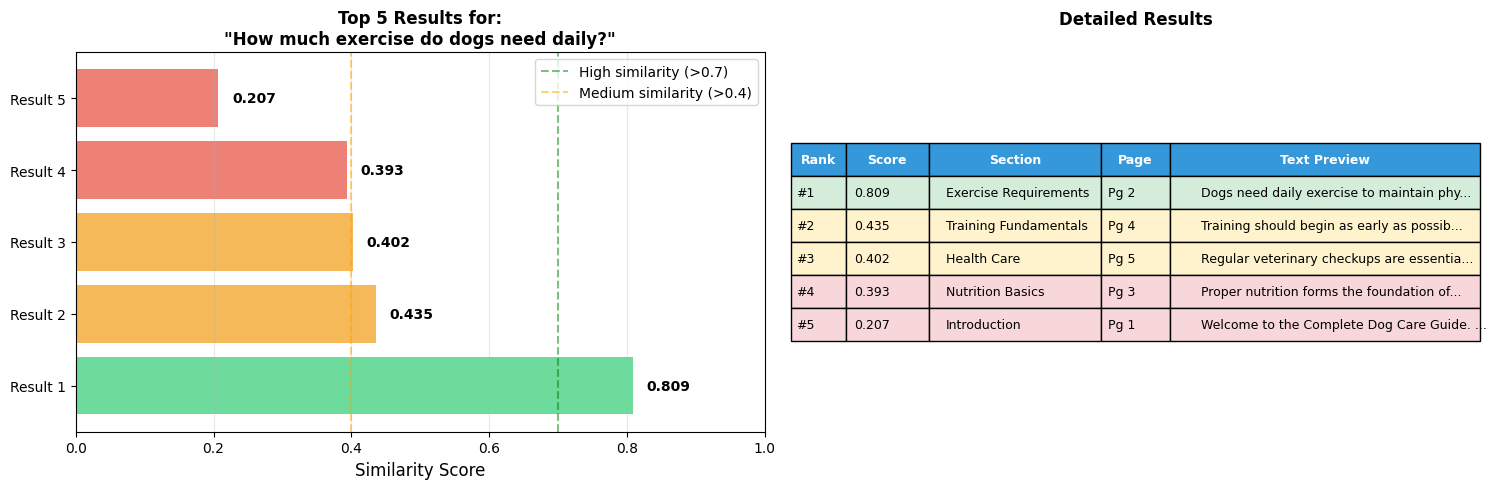


📋 DETAILED RESULTS:

1. Similarity: 0.809 🟢
   Section: Exercise Requirements
   Source: dog_care_complete_guide.pdf, Page 2
   Text: 'Dogs need daily exercise to maintain physical and mental health. A typical 
            adult dog requires at least 30-60 minutes of physical activity per day. 
            This can include walks, runs, fetch games, or swimming. Puppies and high-energy 
            breeds may need even more exercise. Regular activity prevents obesity, 
            reduces behavioral problems, and strengthens the bond between you and your dog.'
   Relevance: HIGH

2. Similarity: 0.435 🟡
   Section: Training Fundamentals
   Source: dog_care_complete_guide.pdf, Page 4
   Text: 'Training should begin as early as possible, ideally when your dog is still 
            a puppy. Start with basic commands: sit, stay, come, down, and heel. 
            Use positive reinforcement techniques - reward good behavior with treats, 
            praise, or play. Be consistent with comman

In [11]:
# ═══════════════════════════════════════════════════════
# 📊 VISUALIZATION: Understanding Retrieval
# ═══════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

print("📊 VISUALIZING SEARCH RESULTS")
print("="*70)

# Test query
query = "How much exercise do dogs need daily?"

print(f"\n🔍 Query: '{query}'")

# Search
results = collection.query(
    query_texts=[query],
    n_results=5  # Get top 5
)

# Extract results
docs = results['documents'][0]
metadatas = results['metadatas'][0]
distances = results['distances'][0]
similarities = [1 - d for d in distances]  # Convert to similarity

# ═══════════════════════════════════════════════════════
# VISUALIZATION 1: Similarity Bar Chart
# ═══════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of similarities
colors = ['#2ecc71' if s > 0.7 else '#f39c12' if s > 0.4 else '#e74c3c'
          for s in similarities]

bars = ax1.barh(range(len(similarities)), similarities, color=colors, alpha=0.7)
ax1.set_yticks(range(len(similarities)))
ax1.set_yticklabels([f"Result {i+1}" for i in range(len(similarities))])
ax1.set_xlabel('Similarity Score', fontsize=12)
ax1.set_title(f'Top {len(similarities)} Results for:\n"{query}"', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='High similarity (>0.7)')
ax1.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='Medium similarity (>0.4)')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, sim) in enumerate(zip(bars, similarities)):
    ax1.text(sim + 0.02, bar.get_y() + bar.get_height()/2,
             f'{sim:.3f}', va='center', fontweight='bold')

# ═══════════════════════════════════════════════════════
# VISUALIZATION 2: Results Table
# ═══════════════════════════════════════════════════════

# Create table data
table_data = []
for i, (doc, meta, sim) in enumerate(zip(docs, metadatas, similarities), 1):
    table_data.append([
        f"#{i}",
        f"{sim:.3f}",
        meta['section'],
        f"Pg {meta['page']}",
        doc[:40] + "..."
    ])

# Remove axes
ax2.axis('tight')
ax2.axis('off')

# Create table
table = ax2.table(
    cellText=table_data,
    colLabels=['Rank', 'Score', 'Section', 'Page', 'Text Preview'],
    cellLoc='left',
    loc='center',
    colWidths=[0.08, 0.12, 0.25, 0.1, 0.45]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows by similarity
for i, sim in enumerate(similarities, 1):
    color = '#d4edda' if sim > 0.7 else '#fff3cd' if sim > 0.4 else '#f8d7da'
    for j in range(5):
        table[(i, j)].set_facecolor(color)

ax2.set_title('Detailed Results', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# Print detailed results
# ═══════════════════════════════════════════════════════

print("\n📋 DETAILED RESULTS:")
print("="*70)
for i, (doc, meta, sim) in enumerate(zip(docs, metadatas, similarities), 1):
    print(f"\n{i}. Similarity: {sim:.3f} {'🟢' if sim > 0.7 else '🟡' if sim > 0.4 else '🔴'}")
    print(f"   Section: {meta['section']}")
    print(f"   Source: {meta['source']}, Page {meta['page']}")
    print(f"   Text: '{doc}'")
    print(f"   Relevance: {'HIGH' if sim > 0.7 else 'MEDIUM' if sim > 0.4 else 'LOW'}")

print("\n" + "="*70)
print("🎯 INTERPRETATION:")
print("Result #1 has highest similarity - it's about exercise! ✅")
print("Lower-ranked results are less relevant to the query.")
print("="*70)